# EfficientNet-B0 with Entropy Filtering, Ordinal Loss, Focal Loss, and LIME Explanations

This notebook trains an EfficientNet-B0 model combining:
- **Entropy filtering**: Removes high-entropy samples for cleaner training
- **Ordinal loss**: Leverages the ordinal nature of ISUP grades (0 < 1 < 2 < 3 < 4 < 5)
- **Focal loss**: Focuses on hard examples and handles class imbalance

The combination addresses multiple challenges:
1. Ordinal structure ensures predictions respect grade ordering
2. Focal loss down-weights easy examples and focuses on hard misclassifications
3. Entropy filtering removes noisy/ambiguous samples

In [1]:
from torch import optim
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights
import torch
import random
import numpy as np
import torch.nn as nn
import torch.nn.functional as F
import albumentations as Albu
import pandas as pd
from torch.utils.data import DataLoader
from torch.utils.data.sampler import RandomSampler
from warmup_scheduler import GradualWarmupScheduler
from sklearn.metrics import accuracy_score, cohen_kappa_score, f1_score, recall_score, precision_score
from tqdm import tqdm
import os
import sys
sys.path.append('../../../')
from utils.dataset import PandasDataset
from utils.models import EfficientNetApi

## Configuration

In [2]:
# Training parameters
seed = 42
batch_size = 3
num_workers = 4
output_classes = 5  # For ordinal encoding: ISUP 0-5 → 5 thresholds
init_lr = 3e-4
warmup_factor = 2
warmup_epochs = 1
n_epochs = 50
dropout_rate = 0.6
patience = 7

# Focal loss parameters
focal_alpha = 0.25  # Weighting factor for focal loss
focal_gamma = 2.0   # Focusing parameter (higher = more focus on hard examples)

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Set seeds
torch.manual_seed(seed)
random.seed(seed)
np.random.seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

# Paths
ROOT_DIR = '../../..'
data_dir = '../../../..'
images_dir = os.path.join(data_dir, 'tiles')

# Output paths
os.makedirs('../logs', exist_ok=True)
os.makedirs('../models', exist_ok=True)
model_path = 'models/b0-entropy-ordinal-focal.pth'
log_path = 'logs/b0-entropy-ordinal-focal.txt'

Using device: cuda


## Combined Ordinal + Focal Loss

This loss function combines:
1. **Ordinal encoding**: Converts ISUP grades to binary thresholds [1,1,...,1,0,0,...,0]
2. **Focal loss modulation**: Applies (1-p_t)^gamma weighting to focus on hard examples

Formula: `FL(p_t) = -alpha * (1 - p_t)^gamma * BCE(logits, ordinal_targets)`

In [3]:
class OrdinalFocalLoss(nn.Module):
    """
    Combined Ordinal + Focal Loss for ordered categories with class imbalance.
    
    Combines ordinal regression (respecting order) with focal loss (handling
    class imbalance and focusing on hard examples).
    
    For each sample with grade k, we create k binary labels:
    - ISUP 0: [0, 0, 0, 0, 0]
    - ISUP 1: [1, 0, 0, 0, 0]
    - ISUP 2: [1, 1, 0, 0, 0]
    - ISUP 3: [1, 1, 1, 0, 0]
    - ISUP 4: [1, 1, 1, 1, 0]
    - ISUP 5: [1, 1, 1, 1, 1]
    
    Then apply focal loss weighting:
    FL(p_t) = -alpha * (1 - p_t)^gamma * log(p_t)
    """
    def __init__(self, alpha=0.25, gamma=2.0, reduction='mean'):
        super(OrdinalFocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction
    
    def forward(self, logits, targets):
        """
        Args:
            logits: (batch_size, num_classes) - raw outputs from model
            targets: (batch_size, num_classes) - ordinal encoded targets
        """
        # Apply sigmoid to get probabilities
        probs = torch.sigmoid(logits)
        
        bce_loss = F.binary_cross_entropy_with_logits(logits, targets, reduction='none')
        
        p_t = probs * targets + (1 - probs) * (1 - targets)
        
        focal_weight = (1 - p_t) ** self.gamma
        
        # Apply focal loss formula
        focal_loss = self.alpha * focal_weight * bce_loss
        
        if self.reduction == 'mean':
            return focal_loss.mean()
        elif self.reduction == 'sum':
            return focal_loss.sum()
        else:
            return focal_loss

def encode_ordinal_labels(labels, num_classes=5):
    """
    Convert categorical labels to ordinal encoding.
    
    Args:
        labels: Tensor or array of ISUP grades (0-5)
        num_classes: Number of thresholds (5 for ISUP 0-5)
    
    Returns:
        Ordinal encoded labels: (batch_size, num_classes)
    """
    if isinstance(labels, torch.Tensor):
        labels = labels.cpu().numpy()
    
    batch_size = len(labels)
    ordinal = torch.zeros((batch_size, num_classes), dtype=torch.float32)
    
    for i, label in enumerate(labels):
        label = int(label)
        if label > 0:
            ordinal[i, :label] = 1
    
    return ordinal

def decode_ordinal_predictions(logits):
    """
    Convert ordinal predictions back to class labels.
    
    Args:
        logits: (batch_size, num_classes) - raw model outputs
    
    Returns:
        Predicted ISUP grades (0-5)
    """
    probs = torch.sigmoid(logits)
    predictions = (probs > 0.5).sum(dim=1)
    return predictions

# Initialize loss function
loss_function = OrdinalFocalLoss(alpha=focal_alpha, gamma=focal_gamma)
print(f"Ordinal + Focal Loss initialized")
print(f"  Alpha: {focal_alpha}")
print(f"  Gamma: {focal_gamma}")

Ordinal + Focal Loss initialized
  Alpha: 0.25
  Gamma: 2.0


## Load Data with Entropy Filtering

In [4]:
# Load original training data
df_train_ = pd.read_csv(f"{ROOT_DIR}/data/train_5fold.csv")
print(f"Original records: {len(df_train_)}")

# Load entropy filtered samples
df_entropy = pd.read_csv(f"{ROOT_DIR}/data/entropy.csv")
print(f"High-entropy samples to remove: {len(df_entropy)}")

df_entropy_sorted = df_entropy.sort_values(by='difficulty_score', ascending=False).reset_index(drop=True)

n_remove = int(len(df_entropy) * 0.2)

df_entropy_top = df_entropy_sorted.head(n_remove)
# Filter out high-entropy samples
df_train_ = df_train_[~df_train_['image_id'].isin(df_entropy_top['image_id'])].reset_index(drop=True)
print(f"Filtered records: {len(df_train_)}")

# Clean column names
df_train_.columns = df_train_.columns.str.strip()

# Split by fold (fold 3 for validation)
train_indexes = np.where(df_train_['fold'] != 3)[0]
valid_indexes = np.where(df_train_['fold'] == 3)[0]

df_train = df_train_.loc[train_indexes].reset_index(drop=True)
df_val = df_train_.loc[valid_indexes].reset_index(drop=True)

# Load test data
df_test = pd.read_csv(f"{ROOT_DIR}/data/test.csv")

def remove_nonexistent_images(df, images_dir):
    """
    Remove rows from df where the image does not exist in images_dir.
    """
    image_ids = df['image_id'].apply(lambda x: os.path.join(images_dir, f"{x}.png"))
    existent_images = [os.path.isfile(path) for path in image_ids]
    df = df[existent_images]
    return df

df_train = remove_nonexistent_images(df_train, images_dir)
df_val = remove_nonexistent_images(df_val, images_dir)
df_test = remove_nonexistent_images(df_test, images_dir)

print(f"\nTrain: {len(df_train)} samples")
print(f"Validation: {len(df_val)} samples")
print(f"Test: {len(df_test)} samples")

# Check class distribution
print(f"\nTrain class distribution:")
print(df_train['isup_grade'].value_counts().sort_index())

Original records: 9024
High-entropy samples to remove: 903
Filtered records: 8844

Train: 7073 samples
Validation: 1767 samples
Test: 1590 samples

Train class distribution:
isup_grade
0    1953
1    1802
2     899
3     826
4     832
5     761
Name: count, dtype: int64


## Data Augmentation

In [5]:
# Augmentation for training
train_transforms = Albu.Compose([
    Albu.Transpose(p=0.5),
    Albu.VerticalFlip(p=0.5),
    Albu.HorizontalFlip(p=0.5),
])

# No augmentation for validation/test
val_transforms = None

## Create Datasets and DataLoaders

In [6]:
# Create datasets
train_dataset = PandasDataset(images_dir, df_train, transforms=train_transforms, format="png")
valid_dataset = PandasDataset(images_dir, df_val, transforms=val_transforms, format="png")
test_dataset = PandasDataset(images_dir, df_test, transforms=val_transforms, format="png")

# Create dataloaders
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    num_workers=num_workers,
    sampler=RandomSampler(train_dataset)
)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=batch_size,
    num_workers=num_workers,
    sampler=RandomSampler(valid_dataset)
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    num_workers=num_workers,
    shuffle=False
)

print(f"Train batches: {len(train_loader)}")
print(f"Validation batches: {len(valid_loader)}")
print(f"Test batches: {len(test_loader)}")

Train batches: 2358
Validation batches: 589
Test batches: 530


## Model Setup

In [7]:
# Load pre-trained EfficientNet-B0
load_model = efficientnet_b0(weights=EfficientNet_B0_Weights.DEFAULT)
model = EfficientNetApi(model=load_model, output_dimensions=output_classes, dropout_rate=dropout_rate)
model = model.to(device)

print(f"Model loaded on {device}")
print(f"Output dimensions: {output_classes} (ordinal thresholds)")
print(f"Dropout rate: {dropout_rate}")

Model loaded on cuda
Output dimensions: 5 (ordinal thresholds)
Dropout rate: 0.6


## Load Pre-trained Model Weights

In [8]:
# Load weights from the trained model
try:
    # Try importing strict weight loading
    try:
        model.load_state_dict(torch.load(model_path, map_location=device, weights_only=True))
    except TypeError:
        # Fallback for older torch versions
        model.load_state_dict(torch.load(model_path, map_location=device))
    print(f"Pre-trained model loaded successfully from {model_path}!")
except Exception as e:
    print(f"Could not load weights: {e}")

Pre-trained model loaded successfully from models/b0-entropy-ordinal-focal.pth!


## Local Interpretable Model-agnostic Explanations (LIME)\n\nEsta seção inclui visualizações LIME adaptando os limiares de classificação (Ordinal Regression) para um formato multiclasse puro para uso no Explicador.

In [ ]:
# !pip install -q lime
import lime
from lime import lime_image
from skimage.segmentation import mark_boundaries, slic
import matplotlib.pyplot as plt
import matplotlib.cm as cm

explainer = lime_image.LimeImageExplainer()

def slic_segmentation(image):
    """
    SLIC segmentation tuned for histopathology: smaller, compact superpixels
    that respect tissue structure better than QuickShift default.
    """
    return slic(
        image,
        n_segments=80,
        compactness=15,
        sigma=1.0,
        start_label=0,
        channel_axis=-1
    )



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [10]:
def predict_proba_ordinal_lime(images):
    """
    Wrapper function for LIME.
    Takes a numpy array of images (N, H, W, C), converts them to Tensor (N, C, H, W)
    in a fully vectorized way, feeds them to the model ON THE GPU, and extracts probabilities.
    """
    model.eval()
    
    # Fast vectorized numpy to torch conversion on GPU
    images_chw = np.transpose(images, (0, 3, 1, 2))
    
    # Send entire batch to GPU directly
    batch_tensor = torch.tensor(images_chw, dtype=torch.float32, device=device)
    
    with torch.no_grad():
        logits = model(batch_tensor)
        probs = torch.sigmoid(logits)
        
    N = probs.shape[0]
    
    # Perform mathematical conversions on the GPU
    class_probs = torch.zeros((N, 6), dtype=torch.float32, device=device)
    
    class_probs[:, 0] = 1.0 - probs[:, 0]
    class_probs[:, 1] = probs[:, 0] - probs[:, 1]
    class_probs[:, 2] = probs[:, 1] - probs[:, 2]
    class_probs[:, 3] = probs[:, 2] - probs[:, 3]
    class_probs[:, 4] = probs[:, 3] - probs[:, 4]
    class_probs[:, 5] = probs[:, 4]
    
    class_probs = torch.clamp(class_probs, 0.0, 1.0)
    row_sums = class_probs.sum(dim=1, keepdim=True)
    row_sums[row_sums == 0] = 1e-6
    class_probs = class_probs / row_sums
    
    # Move back to CPU only at the very end
    return class_probs.cpu().numpy()

In [31]:
from PIL import Image
import os

# Select an image from the test set
sample_idx = 351 # indice otimo acertou classe 5 == 57
image_id = test_dataset.dataframe.iloc[sample_idx]['image_id'].strip()
img_path = f"{images_dir}/{image_id}.png"

print(f"LIME Explaining image: {image_id}.png")

# Use skimage to load it exactly like PandasDataset
original_img = test_dataset.__getitem__(sample_idx)[0].numpy()
original_img_np = np.transpose(original_img, (1, 2, 0)).astype(np.uint8)

# Ground truth
grade_gt = int(test_dataset.dataframe.iloc[sample_idx]['isup_grade'])
print(f"Ground Truth ISUP Grade: {grade_gt}")

# Model prediction
model.eval()
with torch.no_grad():
    sample_tensor = test_dataset.__getitem__(sample_idx)[0].unsqueeze(0).to(device)
    logit = model(sample_tensor)
    pred_grade = decode_ordinal_predictions(logit)[0].item()
    print(f"Predicted ISUP Grade: {pred_grade}")

LIME Explaining image: 2364e13161b373f7d463220e68eea803.png
Ground Truth ISUP Grade: 5
Predicted ISUP Grade: 0


In [32]:
# %%time
# explanation = explainer.explain_instance(
#     original_img_np,
#     predict_proba_ordinal_lime,
#     top_labels=1,
#     hide_color=0,
#     num_samples=500,
#     batch_size=6,
#     segmentation_fn=slic_segmentation
# )

# # --- Heatmap from LIME segment weights ---
# segments = explanation.segments                        # (H, W) int array
# local_exp = explanation.local_exp[pred_grade]          # [(seg_id, weight), ...]

# weight_map = np.zeros(segments.shape, dtype=np.float32)
# for seg_id, weight in local_exp:
#     weight_map[segments == seg_id] = weight

# # Normalize: positive → [0,1], negative → [-1,0], zero-centered
# pos_max = weight_map.max() if weight_map.max() > 0 else 1.0
# neg_min = weight_map.min() if weight_map.min() < 0 else -1.0
# norm_map = np.where(weight_map >= 0, weight_map / pos_max, -weight_map / neg_min)
# # norm_map in [-1, 1]: positive = supports prediction, negative = opposes

# # Map to [0,1] for colormap (RdYlGn: red=opposing, green=supporting)
# heatmap_01 = (norm_map + 1.0) / 2.0
# heatmap_rgba = cm.RdYlGn(heatmap_01)[:, :, :3]       # drop alpha
# heatmap_uint8 = (heatmap_rgba * 255).astype(np.uint8)

# # Alpha-blend: 55% original + 45% heatmap
# alpha = 0.55
# overlay_lime = np.clip(
#     original_img_np.astype(np.float32) * alpha + heatmap_uint8.astype(np.float32) * (1 - alpha),
#     0, 255
# ).astype(np.uint8)

# # Boundary view: only positive (supporting) superpixels
# temp, mask = explanation.get_image_and_mask(
#     pred_grade,
#     positive_only=True,
#     num_features=10,
#     hide_rest=False
# )
# img_boundary = mark_boundaries(temp / 255.0, mask, color=(0, 1, 0), mode='thick')

# # --- Plot ---
# fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# axes[0].imshow(original_img_np)
# axes[0].set_title(f"Original\nGT: {grade_gt}  |  Pred: {pred_grade}", fontsize=13)
# axes[0].axis("off")

# axes[1].imshow(overlay_lime)
# axes[1].set_title("LIME Heatmap Overlay\n(verde = suporte | vermelho = oposição)", fontsize=13)
# axes[1].axis("off")

# axes[2].imshow(img_boundary)
# axes[2].set_title("LIME Superpixels de Suporte\n(bordas verdes = top-10 regiões positivas)", fontsize=13)
# axes[2].axis("off")

# plt.tight_layout()
# os.makedirs("logs", exist_ok=True)
# plt.savefig("logs/lime_explanation_entropy_ordinal.png", dpi=300, bbox_inches="tight")
# plt.show()


In [33]:
import torch
import torch.nn.functional as F
import numpy as np
import cv2
import matplotlib.pyplot as plt


class OrdinalGradCAM:
    """
    Grad-CAM para EfficientNet com cabeça de regressão ordinal.

    Melhorias em relação à versão anterior:
    - Alvo: features[-2] (último bloco MBConv) em vez do último Conv2d do modelo
      inteiro. O bloco MBConv produz gradientes espaciais mais ricos do que a
      conv 1×1 de expansão que vem depois (features[-1]).
    - Score: log(P(classe=predicted_grade)) derivado das probabilidades ordinais,
      em vez de somar logits brutos. Isso foca o gradiente na classe predita.
    - Hook de gradiente registrado no tensor de saída (output.register_hook),
      mais confiável do que register_full_backward_hook em containers Sequential.
    - Normalização por percentil (p2/p98) em vez de min-max, para suprimir
      ativações outlier que colapsariam o contraste nas regiões relevantes.
    """

    def __init__(self, model):
        self.model = model
        self.feature_maps = None
        self.gradient = None
        self._hook_handle = None

        # Alvo explícito: último bloco MBConv de EfficientNet
        target_layer = None
        try:
            target_layer = model.model.features[-2]
            print(f"Grad-CAM target: model.model.features[-2]  ({type(target_layer).__name__})")
        except AttributeError:
            pass

        if target_layer is None:
            # Fallback: último Conv2d encontrado por DFS
            for name, module in model.named_modules():
                if isinstance(module, torch.nn.Conv2d):
                    target_layer = module
                    print(f"Fallback Grad-CAM target: {name}")

        def _forward_hook(module, inp, output):
            self.feature_maps = output
            # Registra hook de gradiente diretamente no tensor de saída.
            # Só funciona quando gradientes estão habilitados.
            if output.requires_grad:
                output.register_hook(lambda g: setattr(self, "gradient", g))

        self._hook_handle = target_layer.register_forward_hook(_forward_hook)

    def __call__(self, x, predicted_grade):
        self.model.eval()
        self.feature_maps = None
        self.gradient = None

        # Forward pass com gradientes ativos para o hook de tensor funcionar
        logits = self.model(x)
        probs = torch.sigmoid(logits)   # (1, 5) limiares ordinais

        # Converte saídas ordinais em probabilidades por classe:
        #   P(grade=0) = 1 - σ(l0)
        #   P(grade=k) = σ(l_{k-1}) - σ(l_k)   para k = 1..4
        #   P(grade=5) = σ(l4)
        n = probs.shape[1]
        class_probs = torch.empty(n + 1, device=logits.device)
        class_probs[0] = 1.0 - probs[0, 0]
        for i in range(1, n):
            class_probs[i] = probs[0, i - 1] - probs[0, i]
        class_probs[n] = probs[0, n - 1]
        class_probs = class_probs.clamp(1e-7, 1.0)

        # Log-probabilidade: gradientes mais localizados do que soma de logits brutos
        score = torch.log(class_probs[predicted_grade])

        self.model.zero_grad()
        score.backward()

        if self.gradient is None or self.feature_maps is None:
            raise RuntimeError(
                "Hooks não capturaram dados. Garanta que torch.grad_enabled(True) "
                "está ativo antes de chamar este método."
            )

        # Grad-CAM: peso de cada canal = média espacial do seu gradiente
        weights = self.gradient.detach().mean(dim=(2, 3), keepdim=True)   # (1, C, 1, 1)
        cam = F.relu((weights * self.feature_maps.detach()).sum(dim=1))    # (H, W)

        cam_np = cam.squeeze().cpu().numpy()

        # Normalização por percentil — robusto contra outliers de ativação
        lo, hi = np.percentile(cam_np, [2, 98])
        cam_np = np.clip((cam_np - lo) / (hi - lo + 1e-8), 0.0, 1.0)

        return cam_np

    def remove_hook(self):
        if self._hook_handle is not None:
            self._hook_handle.remove()


Grad-CAM target: model.model.features[-2]  (Sequential)
Ground Truth: 5  |  Predicted: 0


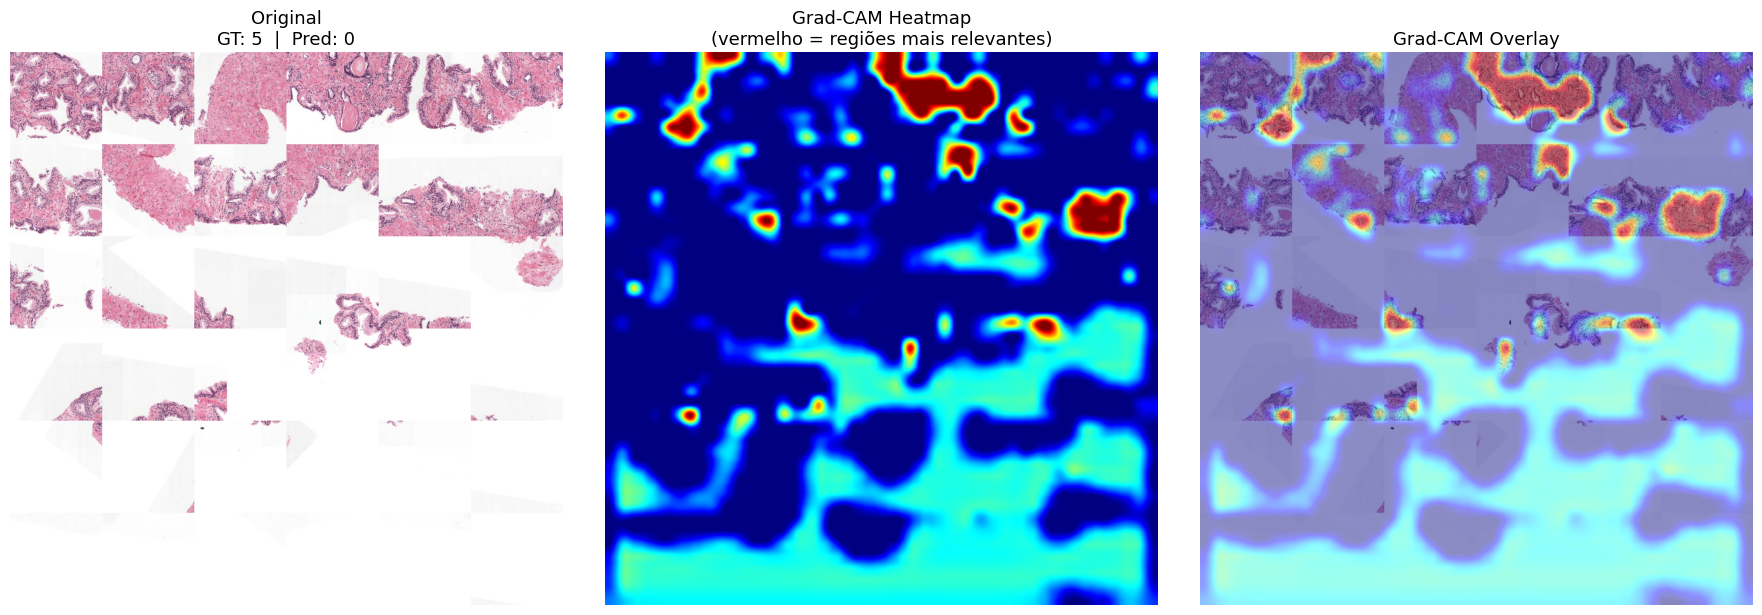

In [34]:
# Instancia o Grad-CAM (hooks são registrados aqui)
grad_cam = OrdinalGradCAM(model)

# --- Predição sem alterar o estado de gradientes ---
model.eval()
with torch.no_grad():
    logit = model(sample_tensor)
    pred_grade = decode_ordinal_predictions(logit)[0].item()

print(f"Ground Truth: {grade_gt}  |  Predicted: {pred_grade}")

# --- Gera o heatmap (requer gradientes ativos) ---
# O hook de tensor só captura gradiente quando requires_grad=True no tensor de saída,
# por isso é necessário habilitar grad antes de chamar grad_cam.
torch.set_grad_enabled(True)
cam_mask = grad_cam(sample_tensor, pred_grade)
torch.set_grad_enabled(False)

# --- Prepara imagem para exibição ---
original_img = test_dataset.__getitem__(sample_idx)[0].numpy()
original_img_np = np.transpose(original_img, (1, 2, 0)).astype(np.uint8)

H, W = original_img_np.shape[:2]

# Upsampling bicúbico: bordas mais suaves do que o linear padrão
cam_resized = cv2.resize(cam_mask, (W, H), interpolation=cv2.INTER_CUBIC)
cam_resized = np.clip(cam_resized, 0.0, 1.0)

heatmap_bgr = cv2.applyColorMap(np.uint8(255 * cam_resized), cv2.COLORMAP_JET)
heatmap_rgb = cv2.cvtColor(heatmap_bgr, cv2.COLOR_BGR2RGB)

# Alpha-blend: 55% original + 45% heatmap mantém detalhes do tecido visíveis
alpha = 0.55
overlay = np.clip(
    original_img_np.astype(np.float32) * alpha + heatmap_rgb.astype(np.float32) * (1 - alpha),
    0, 255
).astype(np.uint8)

# --- Plot ---
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(original_img_np)
axes[0].set_title(f"Original\nGT: {grade_gt}  |  Pred: {pred_grade}", fontsize=13)
axes[0].axis("off")

axes[1].imshow(heatmap_rgb)
axes[1].set_title("Grad-CAM Heatmap\n(vermelho = regiões mais relevantes)", fontsize=13)
axes[1].axis("off")

axes[2].imshow(overlay)
axes[2].set_title("Grad-CAM Overlay", fontsize=13)
axes[2].axis("off")

plt.tight_layout()
os.makedirs("logs", exist_ok=True)
plt.savefig("logs/gradcam_entropy_ordinal_focal.png", dpi=300, bbox_inches="tight")
plt.show()

# Remove hooks para evitar acumulação em re-execuções
grad_cam.remove_hook()
